In [2]:
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")


In [3]:
# Load the data and clear out duplicate entries
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df = df.drop_duplicates()

In [6]:
# Engineer interaction features for prices and efficiency ratios
df["Price_per_km"] = df["Avg_Price_USD"] / df["Range_km"]
df["Eff_Ratio"] = df["Production_Units"] / (df["Estimated_Deliveries"] + 1)


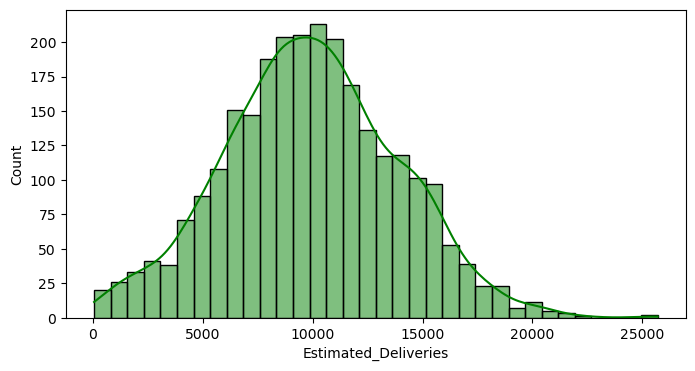

In [7]:
# Display distribution plot for the target variable
plt.figure(figsize=(8, 4))
sns.histplot(df["Estimated_Deliveries"], kde=True, color="green")
plt.show()

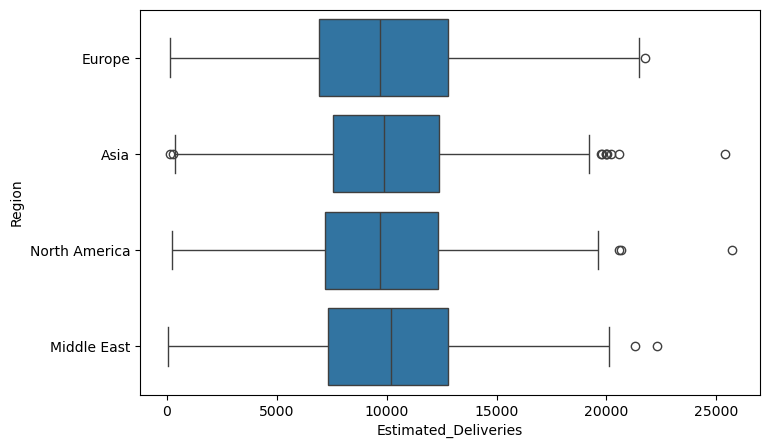

In [8]:
# Display categorical ranges using a boxplot layout
plt.figure(figsize=(8, 5))
sns.boxplot(x="Estimated_Deliveries", y="Region", data=df)
plt.show()

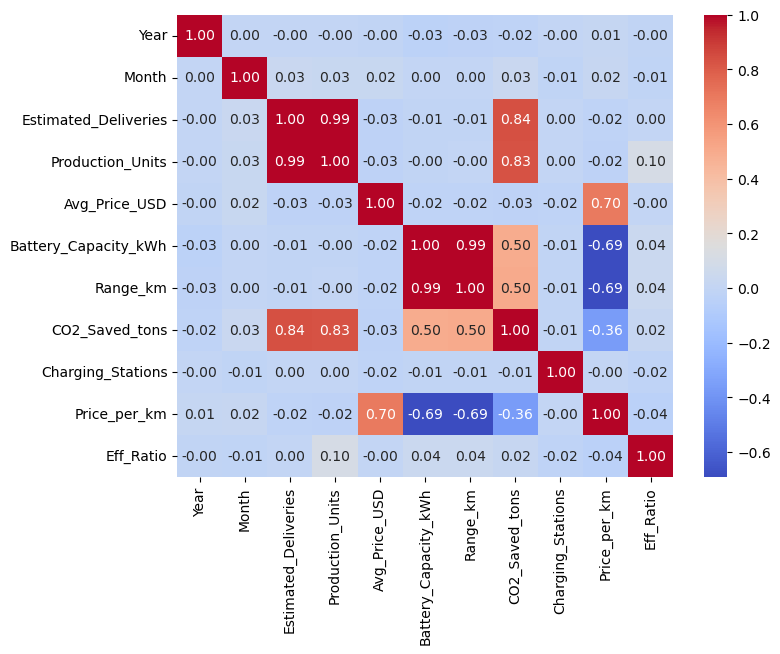

In [9]:
# Display correlation matrix heatmap for numeric attributes
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

In [10]:
# Separate features and target, then split into train and test groups
cats = ["Region", "Model", "Source_Type"]
nums = [
    "Year",
    "Month",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations",
    "Price_per_km",
    "Eff_Ratio",
]

X = df.drop(columns=["Estimated_Deliveries"])
y = df["Estimated_Deliveries"]

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Initialize transformation pipelines for processing numbers and categories
p_num = Pipeline([("imp", SimpleImputer(strategy="median"))])
p_cat = Pipeline(
    [
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

ct = ColumnTransformer([("num", p_num, nums), ("cat", p_cat, cats)])

In [12]:
# Set up pipeline structure and search grids for cross-validation tuning
pipe = Pipeline([("pre", ct), ("reg", RandomForestRegressor(random_state=42))])

grid = {
    "reg__n_estimators": [50, 150],
    "reg__max_depth": [8, 15],
    "reg__min_samples_split": [2, 5],
}

cv = GridSearchCV(pipe, grid, cv=3, scoring="r2", n_jobs=-1)
cv.fit(X_tr, y_tr)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('pre',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imp',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['Year',
                                                                          'Month',
                                                                          'Production_Units',
                                                                          'Avg_Price_USD',
                                                                          'Battery_Capacity_kWh',
                                                                          'Range_km',
                                                                          'CO2_Saved_tons',
                                                                          'Charging_Stations',
                                                                          'Price_per_km',
                                                                          'Eff_Ratio']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imp',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('enc',
                                                                                          OneHotEncoder(handle_unknown='ignore',
                                                                                                        sparse_output=False))]),
                                                                         ['Region',
                                                                          'Model',
                                                                          'Source_Type'])])),
                                       ('reg',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'reg__max_depth': [8, 15],
                         'reg__min_samples_split': [2, 5],
                         'reg__n_estimators': [50, 150]},
             scoring='r2')

In [13]:
# Extract the best estimator configurations and run testing inference
mdl = cv.best_estimator_
pred = mdl.predict(X_te)

In [14]:
# Calculate performance statistics and print evaluation results
mae = mean_absolute_error(y_te, pred)
rmse = np.sqrt(mean_squared_error(y_te, pred))
r2 = r2_score(y_te, pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2: {r2:.2f}")


MAE: 68.63
RMSE: 110.43
R2: 1.00


In [15]:
# Save the trained predictive model to a binary package file
joblib.dump(mdl, "tesla_model.pkl")

['tesla_model.pkl']

In [16]:
# Reconstruct timestamp elements and fit the ARIMA time-series forecaster
df["Date"] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str) + "-01")
ts_df = df.groupby("Date")["Estimated_Deliveries"].sum().sort_index()

ts_model = ARIMA(ts_df, order=(1, 1, 1))
ts_fit = ts_model.fit()

fc = ts_fit.forecast(steps=6)
print(fc)

2026-01-01    201130.711311
2026-02-01    199815.368227
2026-03-01    199605.917021
2026-04-01    199572.564652
2026-05-01    199567.253723
2026-06-01    199566.408027
Freq: MS, Name: predicted_mean, dtype: float64


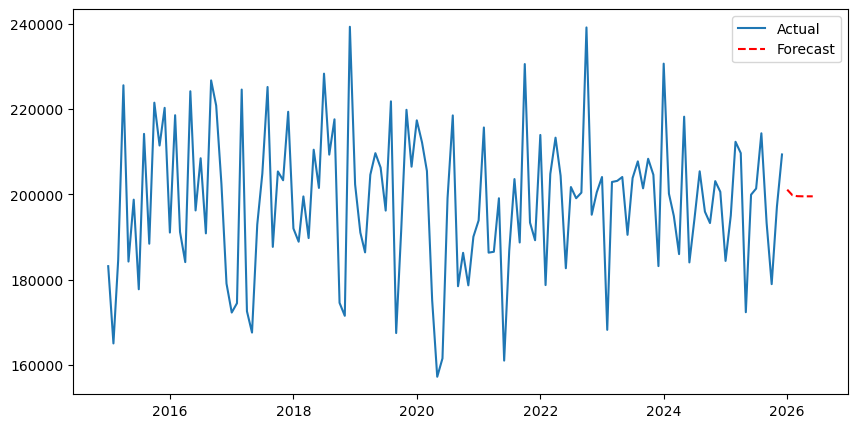

In [17]:
# Plot the historical series records alongside future delivery forecasts
plt.figure(figsize=(10, 5))
plt.plot(ts_df.index, ts_df.values, label="Actual")
plt.plot(fc.index, fc.values, label="Forecast", color="red", linestyle="--")
plt.legend()
plt.show()